In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [3]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float

In [4]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi,2)
    return state

In [5]:
graph = StateGraph(BMIState)
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi',END)

workflow =graph.compile()

In [6]:
final_state= workflow.invoke({'weight_kg':80,'height_m':1.73})
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


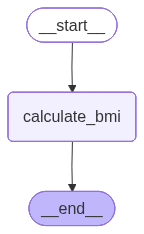

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())